In [1]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

import os


df_train = pd.read_csv("/kaggle/input/datasets/purplecat07/consumer-train-dataset/Consumer_Train_Dataset.csv")
df_test = pd.read_csv("/kaggle/input/datasets/purplecat07/consumer-test-dataset/Consumer_Test_Dataset.csv")

print(df_train.info())

num_cols = ['Age', 'Family_Size','Work_Experience']

bin_cols = ['Ever_Married', 'Graduated']

cat_cols = ['Profession', 'Energy_Consumption', 'Preferred_Renewable', 'Gender']

for col in num_cols:
    df_train[col] = pd.to_numeric(df_train[col], errors='coerce')
    df_test[col] = pd.to_numeric(df_test[col], errors='coerce')

for col in bin_cols:
    df_train[col] = df_train[col].map({
    'Yes': 1,
    'No': 0
    })
    df_test[col] = df_test[col].map({
    'Yes': 1,
    'No': 0
    })

print("Mapping done")
summary_train = pd.DataFrame({
    'Mean': df_train[num_cols].mean(),
    'Median': df_train[num_cols].median(),
    'Std Dev': df_train[num_cols].std()
})

summary_test = pd.DataFrame({
    'Mean': df_test[num_cols].mean(),
    'Median': df_test[num_cols].median(),
    'Std Dev': df_test[num_cols].std()
})


for col in num_cols:
    Q1 = df_test[col].quantile(0.25)
    Q3 = df_test[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_test[col] = df_test[col].clip(lower, upper)
    df_test[col] = df_test[col].fillna(summary_test.Median[col])

    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_train[col] = df_train[col].clip(lower, upper)
    df_train[col] = df_train[col].fillna(summary_train.Median[col])


for col in cat_cols:
    df_train[col] = df_train[col].fillna(df_train[col].mode()[0])
    df_train[col] = df_train[col].astype('category')
    df_test[col] = df_test[col].fillna(df_test[col].mode()[0])
    df_test[col] = df_test[col].astype('category')

for col in bin_cols:
    df_test[col] = df_test[col].fillna(0)
    df_train[col] = df_train[col].fillna(0)

print(df_test.head())
print(df_test.info())
print(df_train.head())
print(df_train.info())

print(summary_test)
print(summary_train)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           8068 non-null   int64  
 1   Gender               8068 non-null   object 
 2   Age                  8068 non-null   int64  
 3   Ever_Married         7928 non-null   object 
 4   Family_Size          7733 non-null   float64
 5   Profession           7944 non-null   object 
 6   Graduated            7990 non-null   object 
 7   Work_Experience      7239 non-null   float64
 8   Energy_Consumption   8068 non-null   object 
 9   Preferred_Renewable  7992 non-null   object 
 10  Group                8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB
None
Mapping done
   Unnamed: 0  Gender   Age  Ever_Married  Family_Size  Profession  Graduated  \
0           0  Female  36.0           1.0          1.0    Engineer        1.0   

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
import os
import pandas as pd

X= df_train[num_cols + bin_cols + cat_cols]
y = df_train['Group']
X_final= df_test[num_cols + bin_cols + cat_cols]

encoder = OrdinalEncoder()
X[cat_cols] = encoder.fit_transform(X[cat_cols])
X_final[cat_cols] = encoder.fit_transform(X_final[cat_cols])


# # One-hot encode categorical columns
# X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

num_features = num_cols 

ct = ColumnTransformer([
    ('scale', StandardScaler(), num_features)
], remainder='passthrough')


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = ct.fit_transform(X_train)
X_test = ct.fit_transform(X_test)
X_final = ct.fit_transform(X_final)

/tmp/ipykernel_16/608312829.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[cat_cols] = encoder.fit_transform(X[cat_cols])
/tmp/ipykernel_16/608312829.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_final[cat_cols] = encoder.fit_transform(X_final[cat_cols])


      Iter       Train Loss   Remaining Time 
         1           1.3336            2.62s
         2           1.2949            2.34s
         3           1.2635            2.24s
         4           1.2381            2.18s
         5           1.2152            2.13s
         6           1.1966            2.08s
         7           1.1799            2.05s
         8           1.1658            2.01s
         9           1.1533            1.99s
        10           1.1424            1.97s
        20           1.0788            1.73s
        30           1.0499            1.50s
        40           1.0319            1.29s
        50           1.0194            1.08s
        60           1.0093            0.86s
        70           1.0002            0.64s
        80           0.9923            0.43s
        90           0.9855            0.21s
       100           0.9792            0.00s


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished



Logistic Regression
Accuracy: 0.483271375464684
              precision    recall  f1-score   support

           A       0.39      0.43      0.41       391
           B       0.39      0.13      0.19       369
           C       0.43      0.58      0.50       380
           D       0.63      0.72      0.67       474

    accuracy                           0.48      1614
   macro avg       0.46      0.47      0.44      1614
weighted avg       0.47      0.48      0.46      1614



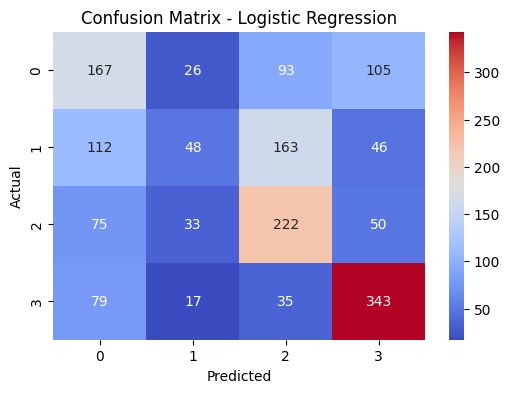


Random Forest
Accuracy: 0.530359355638166
              precision    recall  f1-score   support

           A       0.44      0.43      0.43       391
           B       0.44      0.36      0.40       369
           C       0.54      0.56      0.55       380
           D       0.65      0.72      0.68       474

    accuracy                           0.53      1614
   macro avg       0.52      0.52      0.52      1614
weighted avg       0.52      0.53      0.53      1614



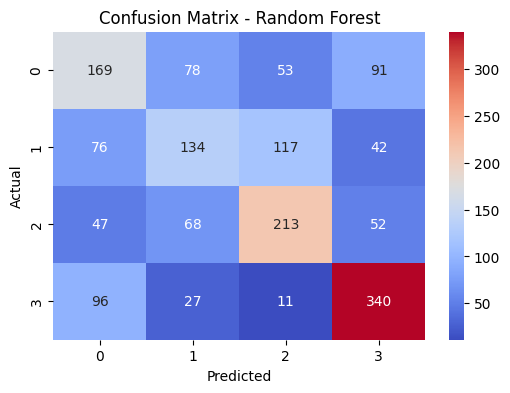


Gradient Boosting
Accuracy: 0.5353159851301115
              precision    recall  f1-score   support

           A       0.43      0.44      0.43       391
           B       0.43      0.34      0.38       369
           C       0.56      0.58      0.57       380
           D       0.66      0.73      0.69       474

    accuracy                           0.54      1614
   macro avg       0.52      0.52      0.52      1614
weighted avg       0.53      0.54      0.53      1614



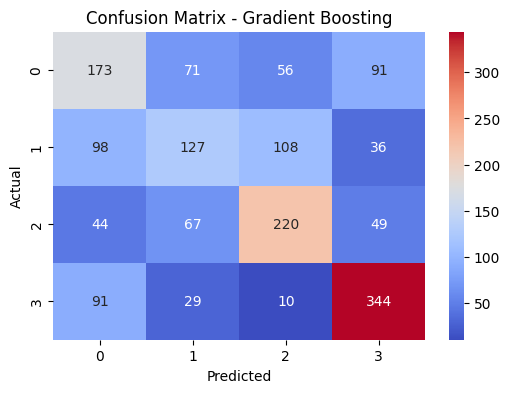


Extra Trees Classifier
Accuracy: 0.476456009913259
              precision    recall  f1-score   support

           A       0.38      0.37      0.37       391
           B       0.36      0.36      0.36       369
           C       0.49      0.49      0.49       380
           D       0.63      0.65      0.64       474

    accuracy                           0.48      1614
   macro avg       0.46      0.47      0.47      1614
weighted avg       0.47      0.48      0.48      1614



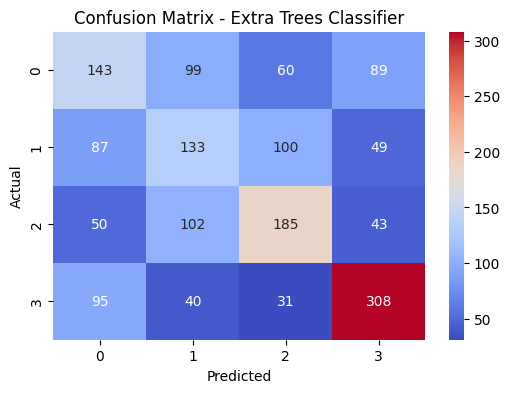


SVM
Accuracy: 0.5117719950433705
              precision    recall  f1-score   support

           A       0.42      0.48      0.45       391
           B       0.38      0.36      0.37       369
           C       0.53      0.50      0.52       380
           D       0.69      0.66      0.68       474

    accuracy                           0.51      1614
   macro avg       0.51      0.50      0.50      1614
weighted avg       0.52      0.51      0.51      1614



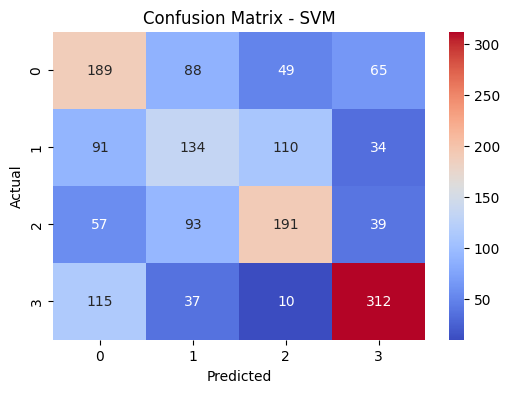

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

gb = GradientBoostingClassifier(verbose=1)

gb.fit(X_train, y_train)


lr = LogisticRegression(max_iter=1000,verbose=1)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)

et = ExtraTreesClassifier(n_estimators=200, random_state=42)
et.fit(X_train, y_train)


svm = SVC(
    kernel='rbf',
    C=10,
    gamma=0.01,
    class_weight='balanced',
    probability=True
)

svm.fit(X_train, y_train)


models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "Extra Trees Classifier":et,
    "SVM": svm
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred)
    })    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap = 'coolwarm')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [4]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt



best_model = gb   
predictions = best_model.predict(X_final)


output = pd.DataFrame({
    "Group": predictions
})

output.to_csv("25B2244_q_2.csv", index=False)

print("done")

done
